In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
import torchvision
from torchvision import datasets, models, transforms
import matplotlib.pyplot as plt
import numpy as np
import time
import os
import copy
from google.colab import drive

In [ ]:
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
DATA_DIR = '/content/drive/MyDrive/dataset'

In [ ]:
BATCH_SIZE = 32

In [ ]:
data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((224, 224)),       # ResNet expects 224x224
        transforms.RandomHorizontalFlip(),   # Augmentation: Flip image
        transforms.RandomRotation(10),       # Augmentation: Slight rotation
        transforms.ToTensor(),               # Convert to Tensor
        # Normalize using ImageNet means (standard for Transfer Learning)
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

In [ ]:
image_datasets = {x: datasets.ImageFolder(os.path.join(DATA_DIR, x),
                                          data_transforms[x])
                  for x in ['train', 'val']}

dataloaders = {x: torch.utils.data.DataLoader(image_datasets[x], batch_size=BATCH_SIZE,
                                             shuffle=True, num_workers=2)
              for x in ['train', 'val']}

dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val']}
class_names = image_datasets['train'].classes
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

print(f"Classes found: {class_names}")
print(f"Using device: {device}")

Classes found: ['angiogram', 'non_angiogram']
Using device: cuda:0


In [ ]:
def train_model(model, criterion, optimizer, scheduler, num_epochs=25):
    since = time.time()

    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0

    for epoch in range(num_epochs):
        print(f'Epoch {epoch + 1}/{num_epochs}')
        print('-' * 10)

        # Each epoch has a training and validation phase
        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()  # Set model to training mode
            else:
                model.eval()   # Set model to evaluate mode

            running_loss = 0.0
            running_corrects = 0

            # Iterate over data
            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)

                # Zero the parameter gradients
                optimizer.zero_grad()

                # Forward
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    # Backward + optimize only if in training phase
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                # Statistics
                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            if phase == 'train':
                scheduler.step()

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]

            print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

            # Deep copy the model if it's the best one so far
            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())
                torch.save(model.state_dict(), 'best_angiogram_model.pth') # Save locally

    time_elapsed = time.time() - since
    print(f'Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
    print(f'Best val Acc: {best_acc:4f}')

    # Load best model weights
    model.load_state_dict(best_model_wts)
    return model

In [ ]:
print("Initializing ResNet18...")
model_ft = models.resnet18(pretrained=True)

# Freeze initial layers (Optional: un-comment to freeze)
# for param in model_ft.parameters():
#     param.requires_grad = False

# ResNet18's final layer (fc) has 512 inputs.
# We replace it with a layer having 2 outputs (Angiogram vs Non-Angiogram)
num_ftrs = model_ft.fc.in_features
model_ft.fc = nn.Linear(num_ftrs, 2)

model_ft = model_ft.to(device)

Initializing ResNet18...


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 183MB/s]


In [ ]:
criterion = nn.CrossEntropyLoss()

# Observe that all parameters are being optimized
optimizer_ft = optim.SGD(model_ft.parameters(), lr=0.001, momentum=0.9)

# Decay LR by a factor of 0.1 every 7 epochs (Helps convergence)
exp_lr_scheduler = lr_scheduler.StepLR(optimizer_ft, step_size=7, gamma=0.1)

In [ ]:
model_ft = train_model(model_ft, criterion, optimizer_ft, exp_lr_scheduler, num_epochs=15)

Epoch 1/15
----------
train Loss: 0.0634 Acc: 0.9800
val Loss: 0.0043 Acc: 1.0000
Epoch 2/15
----------
train Loss: 0.0055 Acc: 0.9996
val Loss: 0.0016 Acc: 1.0000
Epoch 3/15
----------
train Loss: 0.0037 Acc: 0.9998
val Loss: 0.0008 Acc: 1.0000
Epoch 4/15
----------
train Loss: 0.0027 Acc: 0.9998
val Loss: 0.0007 Acc: 1.0000
Epoch 5/15
----------
train Loss: 0.0047 Acc: 0.9983
val Loss: 0.0006 Acc: 1.0000
Epoch 6/15
----------
train Loss: 0.0023 Acc: 0.9998
val Loss: 0.0004 Acc: 1.0000
Epoch 7/15
----------
train Loss: 0.0015 Acc: 1.0000
val Loss: 0.0003 Acc: 1.0000
Epoch 8/15
----------
train Loss: 0.0010 Acc: 1.0000
val Loss: 0.0003 Acc: 1.0000
Epoch 9/15
----------
train Loss: 0.0016 Acc: 0.9998
val Loss: 0.0004 Acc: 1.0000
Epoch 10/15
----------
train Loss: 0.0021 Acc: 0.9996
val Loss: 0.0003 Acc: 1.0000
Epoch 11/15
----------
train Loss: 0.0013 Acc: 1.0000
val Loss: 0.0003 Acc: 1.0000
Epoch 12/15
----------
train Loss: 0.0011 Acc: 1.0000
val Loss: 0.0003 Acc: 1.0000
Epoch 13/15
-

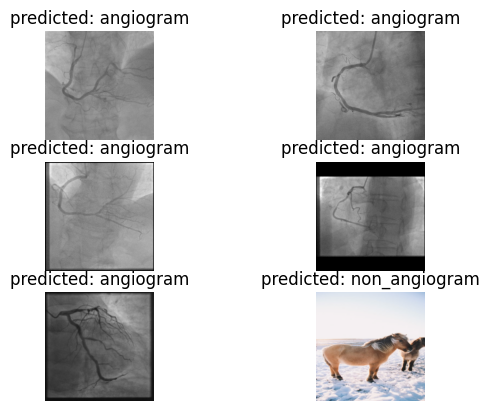

In [ ]:
def visualize_model(model, num_images=6):
    was_training = model.training
    model.eval()
    images_so_far = 0
    fig = plt.figure()

    with torch.no_grad():
        for i, (inputs, labels) in enumerate(dataloaders['val']):
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            for j in range(inputs.size()[0]):
                images_so_far += 1
                ax = plt.subplot(num_images//2, 2, images_so_far)
                ax.axis('off')
                ax.set_title(f'predicted: {class_names[preds[j]]}')

                # Undo normalization for display
                img = inputs.cpu().data[j].numpy().transpose((1, 2, 0))
                mean = np.array([0.485, 0.456, 0.406])
                std = np.array([0.229, 0.224, 0.225])
                img = std * img + mean
                img = np.clip(img, 0, 1)

                plt.imshow(img)

                if images_so_far == num_images:
                    model.train(mode=was_training)
                    return
        model.train(mode=was_training)

visualize_model(model_ft)

Classification Report:
               precision    recall  f1-score   support

    angiogram       1.00      1.00      1.00       650
non_angiogram       1.00      1.00      1.00       687

     accuracy                           1.00      1337
    macro avg       1.00      1.00      1.00      1337
 weighted avg       1.00      1.00      1.00      1337



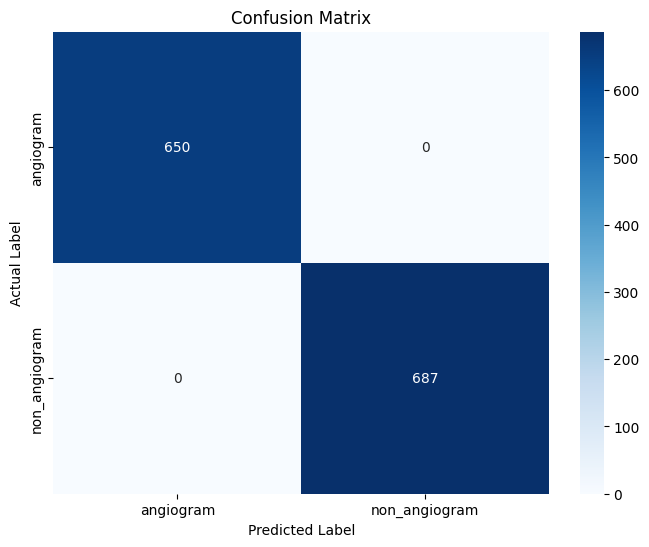

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import pandas as pd

def evaluate_performance(model, dataloader):
    model.eval() # Set model to evaluation mode
    y_true = []
    y_pred = []

    # Disable gradient calculation for speed
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            # Move to CPU to use with sklearn
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    # 1. Calculate Metrics
    print("Classification Report:")
    # This prints Precision, Recall, and F1-Score for each class
    print(classification_report(y_true, y_pred, target_names=class_names))

    # 2. Generate Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)

    # Plotting
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.ylabel('Actual Label')
    plt.xlabel('Predicted Label')
    plt.title('Confusion Matrix')
    plt.show()

# Run the evaluation on the Validation Set
evaluate_performance(model_ft, dataloaders['val'])

In [ ]:
save_path = '/content/drive/MyDrive/angiogram_resnet18_weight.pth'
torch.save(model_ft.state_dict(), save_path)
print(f"Model weights saved to: {save_path}")

Model weights saved to: /content/drive/MyDrive/angiogram_resnet18_weight.pth


In [ ]:
# Useful if you don't want to redefine the class later, but larger file size.
full_model_path = '/content/drive/MyDrive/angiogram_resnet18_full.pth'
torch.save(model_ft, full_model_path)
print(f"Full model saved to: {full_model_path}")

Full model saved to: /content/drive/MyDrive/angiogram_resnet18_full.pth


In [ ]:
from google.colab import files
files.download('/content/drive/MyDrive/angiogram_resnet18_weight.pth')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>